# Linear Regression on Hardware Data
This notebook demonstrates how to generate synthetic hardware data and apply linear regression to predict power consumption based on multiple hardware metrics.

In [ ]:
%pip install statsmodels seaborn

In [6]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [7]:
data = pd.read_csv('hardware_info.csv')

## Split the Data
We will split the data into training and testing sets.

In [8]:

# Split the data into training and testing sets
X = data[['CPU_Usage', 'RAM_Usage', 'Disk_IO', 'Network_In', 'Network_Out', 'Temperature', 'Fan_Speed', 'Voltage']]
y = data['Power_Consumption'] # dependent feature
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Display the shapes of the train and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((800, 8), (200, 8), (800,), (200,))

## Train the Linear Regression Model
We will create and train a linear regression model using the training data.

In [9]:

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Display the coefficients
print(f'Intercept: {model.intercept_}')
print(f'Coefficients: {model.coef_}')


Intercept: 30.958724204780253
Coefficients: [1.4914861  0.50889614 0.00999507 0.01978859 0.0195227  0.48699029
 0.01013422 9.66216749]


## Make Predictions
We will use the trained model to make predictions on the test data.

In [11]:
X_test

,CPU_Usage,RAM_Usage,Disk_IO,Network_In,Network_Out,Temperature,Fan_Speed,Voltage
521,38.089086,93.443603,134.435129,469.107211,577.117082,54.641204,1635.394450,1.252905
737,81.659944,19.462251,544.482333,751.177137,348.831907,35.966082,1011.490872,1.104326
740,46.267979,82.753790,365.680748,904.359775,718.718113,73.458433,1513.257901,1.301878
660,35.609673,60.059433,472.281804,509.854010,511.113638,31.046079,2716.851444,1.019181
411,95.006197,11.191962,140.552968,130.080670,4.187444,36.408471,2056.692925,1.223344
...,...,...,...,...,...,...,...,...
408,90.538198,58.535436,988.035966,241.496485,382.139475,39.259823,2536.265730,1.087858
332,1.439349,22.845474,603.795453,169.881006,439.855640,25.218021,2614.283992,1.471093
208,0.506158,27.362667,292.218230,439.210601,86.032157,72.172020,2206.781241,1.191582
613,8.175903,32.433375,740.904056,797.732263,109.013616,34.679303,1109.022245,1.198593


In [10]:

# Make predictions
y_pred = model.predict(X_test)

# Display the first few predictions
y_pred[:5]


array([212.50365706, 228.21066584, 241.35037942, 191.92197536,
       232.80909906])

## Plot the Results
We will plot the actual vs predicted power consumption values.

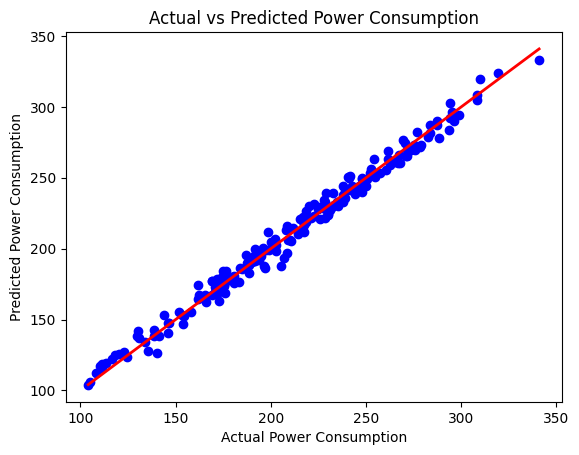

In [12]:

# Plot the results
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Power Consumption')
plt.ylabel('Predicted Power Consumption')
plt.title('Actual vs Predicted Power Consumption')
plt.show()


## Evaluate the Model
We will evaluate the model using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), R-squared (R²) score, and Adjusted R-squared.

In [13]:

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error: {mape}%')
print(f'R-squared: {r2}')
print(f'Adjusted R-squared: {adj_r2}')


Mean Absolute Error: 4.403836614140015
Mean Squared Error: 30.194636637892128
Root Mean Squared Error: 5.494964662114955
Mean Absolute Percentage Error: 2.23009793577984%
R-squared: 0.9879578094650721
Adjusted R-squared: 0.9874534245212008


## Check Assumptions of Linear Regression
We will check the assumptions of linear regression to validate the model.

### Linearity
The relationship between the independent and dependent variables should be linear.

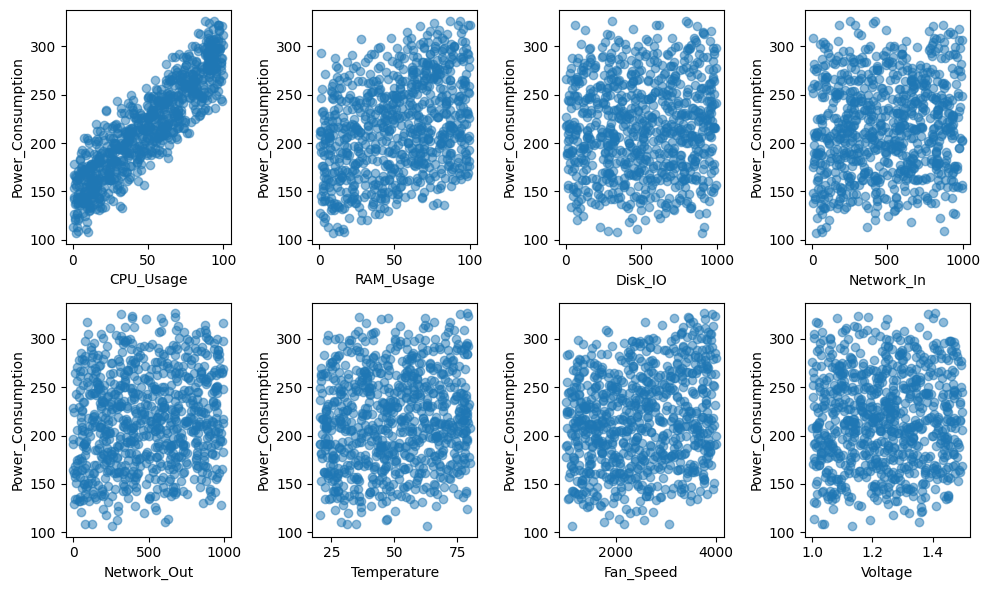

In [14]:

# Linearity
plt.figure(figsize=(10, 6))
for i, col in enumerate(X_train.columns, 1):
    plt.subplot(2, 4, i)
    plt.scatter(X_train[col], y_train, alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('Power_Consumption')
plt.tight_layout()
plt.show()


### Independence
The residuals(actual - predicted) should be independent (no patterns).

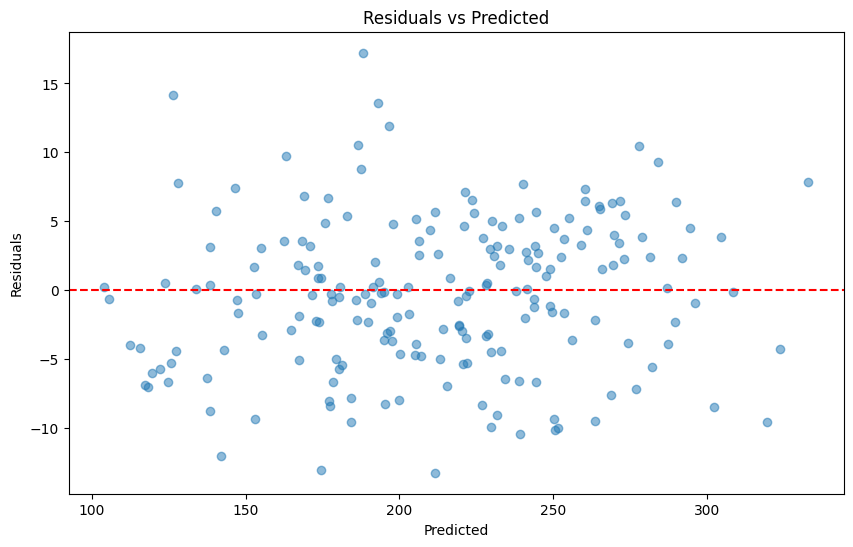

In [15]:

# Independence
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()


### Homoscedasticity
The residuals should have constant variance.

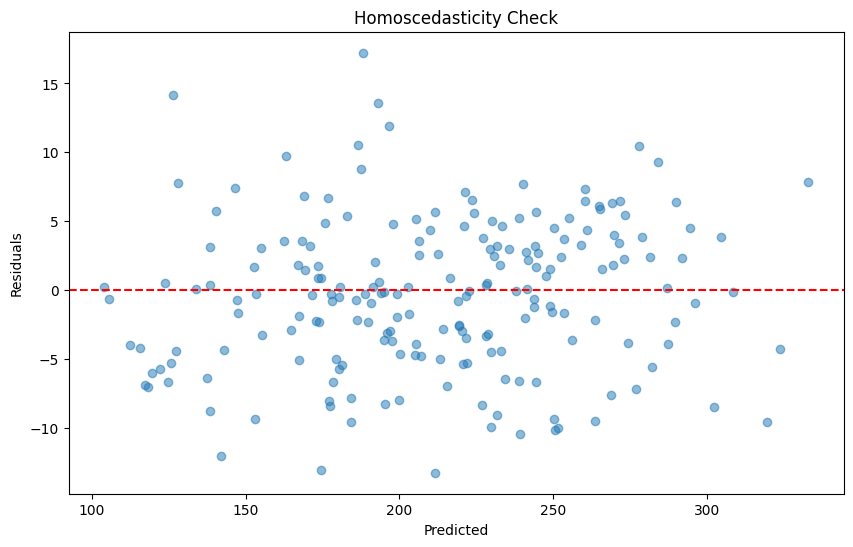

In [16]:

# Homoscedasticity
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check')
plt.show()


### Normality of Residuals
The residuals should be normally distributed.

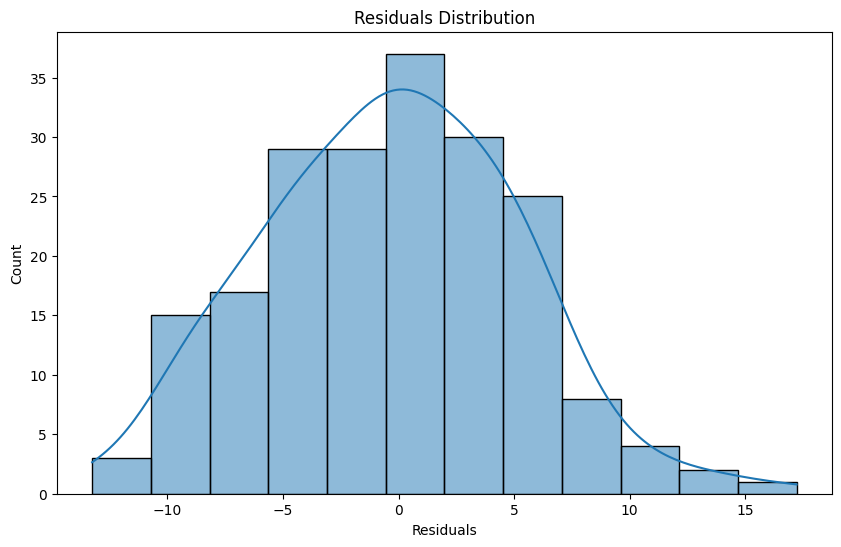

In [17]:

# Normality of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')
plt.show()




## Variance Inflation Factor (VIF)
We will calculate VIF to check for multicollinearity among the independent variables.

In [ ]:

# Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)


## Heatmap
We will plot a heatmap to visualize the correlation between features.

In [ ]:

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## Correlation Matrix
We will display the correlation matrix.

In [ ]:

# Correlation Matrix
corr_matrix = data.corr()
print(corr_matrix)
